In [97]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier  
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  


from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from skopt

SyntaxError: invalid syntax (4145359221.py, line 16)

In [ ]:
data = pd.read_csv('../dataset/CreditScoring.csv')
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
data.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [ ]:
data.columns

Index(['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG',
       'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC'],
      dtype='str')

In [ ]:
data.shape

(5960, 13)

In [ ]:
data.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [ ]:
data.isnull().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [ ]:
data = data.dropna()

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
print("Number of unique Reason columns " , data['REASON'].nunique())
print("Number of unique Job columns ", data['JOB'].nunique())

Number of unique Reason columns  2
Number of unique Job columns  6


In [ ]:
unique_BAD1 = (data['BAD']== 1).sum()
print("Number of Bad = 1" , unique_BAD1)

unique_BAD0 = (data['BAD']== 0).sum()

print("Number of Bad = 0 " , unique_BAD0)

Number of Bad = 1 300
Number of Bad = 0  3064


<Axes: xlabel='JOB', ylabel='LOAN'>

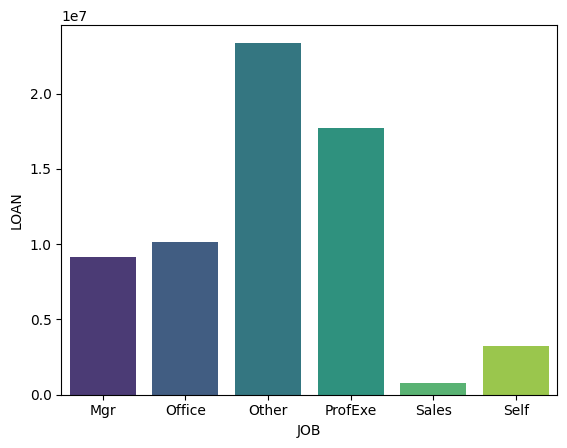

In [ ]:
loan_by_job = data.groupby('JOB')['LOAN'].sum().reset_index()

sns.barplot(data = loan_by_job , x = 'JOB' , y = 'LOAN' , palette = 'viridis' , hue = 'JOB' , legend = False)

<Axes: xlabel='REASON', ylabel='LOAN'>

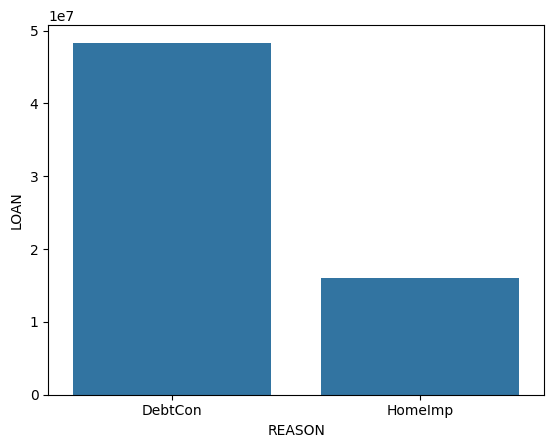

In [ ]:
loan_by_reason = data.groupby("REASON")["LOAN"].sum().reset_index()

sns.barplot(data = loan_by_reason , x = "REASON" , y = "LOAN" , hue =None , legend= False)

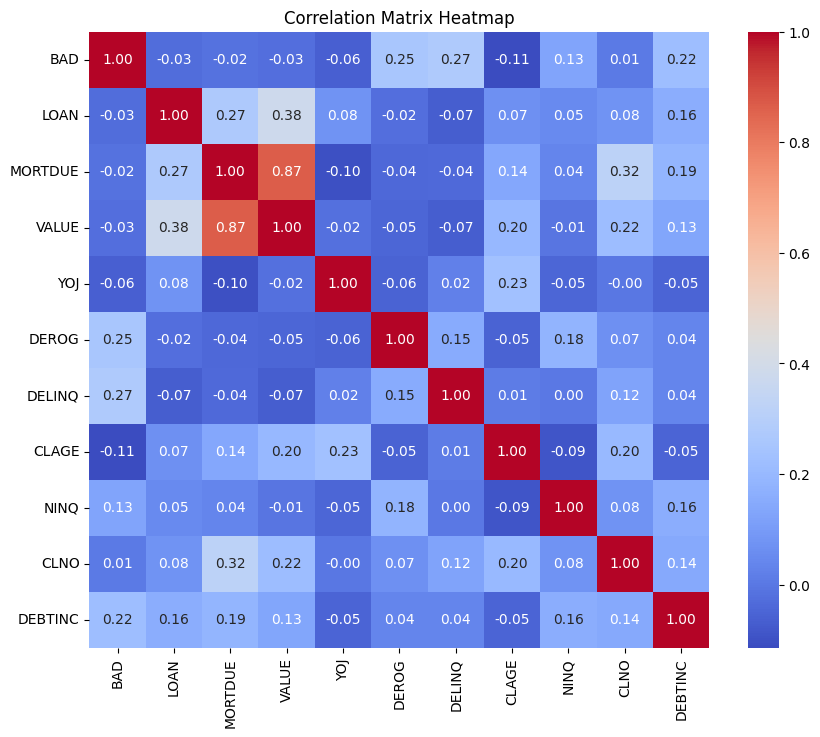

In [ ]:
numerical_dataset = data.select_dtypes(include = [np.number])
correlation_matrix = numerical_dataset.corr(method='pearson')

plt.figure(figsize=(10 , 8 ))
sns.heatmap(correlation_matrix , annot= True , cmap= "coolwarm" , fmt = '.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output= False)

categorical_features = data[["REASON" , "JOB"]]
encoded_data = encoder.fit_transform(categorical_features)
encoded_df = pd.DataFrame(
    encoded_data,
    columns = encoder.get_feature_names_out(categorical_features.columns),
    index = data.index
)

data_encoded = data.drop(columns= categorical_features.columns).join(encoded_df)

data_encoded.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_DebtCon,REASON_HomeImp,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
5,1,1700,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
7,1,1800,28502.0,43034.0,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
19,0,2300,102370.0,120953.0,2.0,0.0,0.0,90.992533,0.0,13.0,31.588503,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25,1,2400,34863.0,47471.0,12.0,0.0,0.0,70.491080,1.0,21.0,38.263601,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
26,0,2400,98449.0,117195.0,4.0,0.0,0.0,93.811775,0.0,13.0,29.681827,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X= data_encoded.drop("BAD" , axis = 1)
y = data_encoded["BAD"]

print(X.columns)

X_train ,X_test , y_train , y_test = train_test_split(X , y , test_size= 0.33 , random_state= 42 , stratify=y)

Index(['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ',
       'CLNO', 'DEBTINC', 'REASON_DebtCon', 'REASON_HomeImp', 'JOB_Mgr',
       'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self'],
      dtype='str')


------------------------------------------------------------
Metrics of the Decision Tree Classifier algorithm 
------------------------------------------------------------
Accuracy :  0.9486948694869487
F1 - Score : 0.6885245901639344
Precision :  0.75
Recall :  0.6363636363636364
Confusion Matrix :       0   1
0  991  21
1   36  63


Text(50.722222222222214, 0.5, 'Actual')

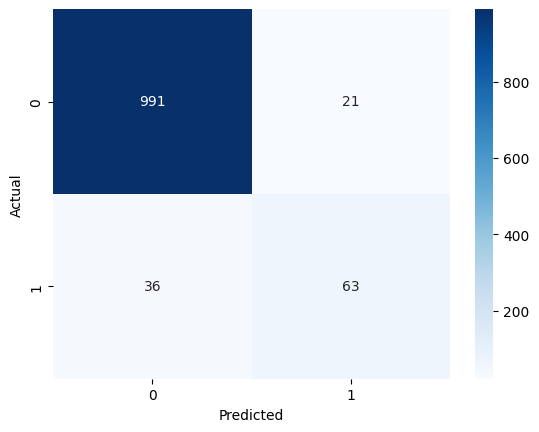

In [ ]:
decisionTree = DecisionTreeClassifier(
    criterion= 'gini',
)


decisionTree.fit(X_train , y_train)

print("-"* 60)
print("Metrics of the Decision Tree Classifier algorithm ")
print("-"* 60)
y_predicted = decisionTree.predict(X_test)

accuracy = metrics.accuracy_score(y_test , y_predicted )
print("Accuracy : " , accuracy)

f1_score = metrics.f1_score(y_test , y_predicted  )
print("F1 - Score :" , f1_score)

precision = metrics.precision_score(y_test , y_predicted )
print("Precision : " ,precision )

recall =metrics.recall_score(y_test , y_predicted   ) 
print("Recall : " , recall )

confusion_matrix = pd.DataFrame(metrics.confusion_matrix(y_test , y_predicted))
print("Confusion Matrix : " , confusion_matrix)
sns.heatmap(confusion_matrix , annot=True , fmt = 'd' , cmap =  'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(DecisionTreeClassifier() , param_grid= param_grid , cv = 5)
grid_search.fit(X_train , y_train)

print("Best Parameters: " , grid_search.best_params_)
print("Best Estimator: " , grid_search.best_estimator_)

NameError: name 'GridSearchCV' is not defined

------------------------------------------------------------
Metrics of the Random Forest Classifier
------------------------------------------------------------
accuracy score :  0.954995499549955
F1-score : 0.6621621621621622
Precision : 1.0
Recall : 0.494949494949495


Text(50.722222222222214, 0.5, 'Actual')

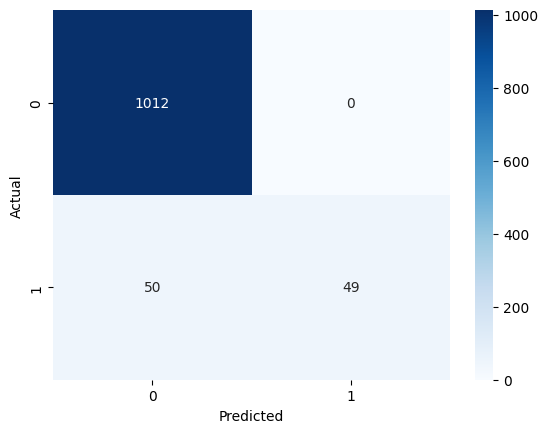

In [ ]:
random_forest = RandomForestClassifier()

random_forest.fit(X_train , y_train)
y_predicted_RF =random_forest.predict(X_test)

print("-"*60)
print("Metrics of the Random Forest Classifier")
print("-"*60)

accuracy_RF = metrics.accuracy_score(y_test , y_predicted_RF)
print("accuracy score : ", accuracy_RF)

f1_score_RF = metrics.f1_score(y_test , y_predicted_RF)
print("F1-score :" , f1_score_RF)

precision_RF = metrics.precision_score(y_test , y_predicted_RF)
print("Precision :" , precision_RF)

recall_RF = metrics.recall_score(y_test , y_predicted_RF)
print("Recall :" ,recall_RF)

confusion_matrix_RF = metrics.confusion_matrix(y_test , y_predicted_RF)
sns.heatmap(confusion_matrix_RF , annot= True , fmt ='d' ,cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

------------------------------------------------------------
Metrics of the XGB Classifier
------------------------------------------------------------
accuracy score :  0.9612961296129613
F1-score : 0.7329192546583851
Precision : 0.9516129032258065
recall : 0.5959595959595959


Text(50.722222222222214, 0.5, 'Actual')

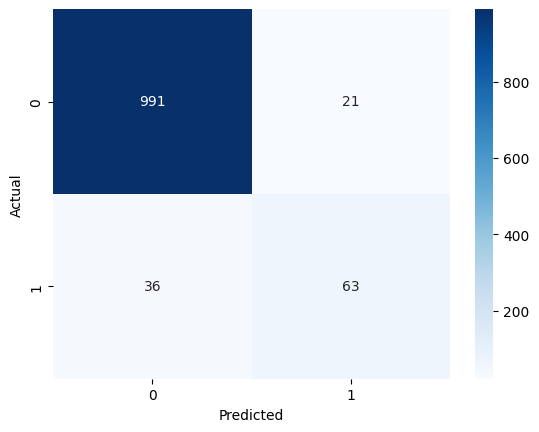

In [ ]:
xgboost = XGBClassifier()

xgboost.fit(X_train , y_train)
y_predicted_xg = xgboost.predict(X_test)

print("-"*60)
print("Metrics of the XGB Classifier")
print("-"*60)

accuracy_xg = metrics.accuracy_score(y_test ,y_predicted_xg)
print("accuracy score : ",accuracy_xg)

f1_score_xg = metrics.f1_score(y_test, y_predicted_xg )
print("F1-score :" , f1_score_xg)

precision_xg = metrics.precision_score(y_test , y_predicted_xg  )
print("Precision :" , precision_xg)

recall_xg = metrics.recall_score(y_test , y_predicted_xg)
print("recall :" , recall_xg)

confusion_matrix_xg = metrics.confusion_matrix(y_test , y_predicted_xg)

sns.heatmap(confusion_matrix ,annot= True  , fmt='d' ,  cmap = 'Blues' )
plt.xlabel("Predicted")
plt.ylabel("Actual")